# **Logistic Regression from Scratch**
## *Applied to: Breast Cancer Wisconsin (Diagnostic)*

Given 30 numerical features computed from digitized images of breast tissue, classify each tumor as:
- $y = 1$ $\to$ **Malignant**
- $y = 0$ $\to$ **Benign**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
 

## **The Classification Problem**

In **binary classification**, the label $y$ takes only two values:

$$y \in \{0, 1\}$$

Linear Regression is unsuitable here because its hypothesis $h_\theta(x) = \theta^T x$ can produce values outside $[0, 1]$, which are not valid probabilities. We need a function that maps any real-valued input to the interval $(0, 1)$.

## **The Sigmoid Function**

The sigmoid function is defined as:

$$g(z) = \frac{1}{1 + e^{-z}}$$

The Logistic Regression hypothesis is:

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

**Key properties:**
- $g(z) \in (0, 1)$ for all $z \in \mathbb{R}$
- $g(0) = 0.5$
- $g(z) \to 1$ as $z \to +\infty$; $g(z) \to 0$ as $z \to -\infty$
- Derivative: $g'(z) = g(z)(1 - g(z))$ (we will use it later)

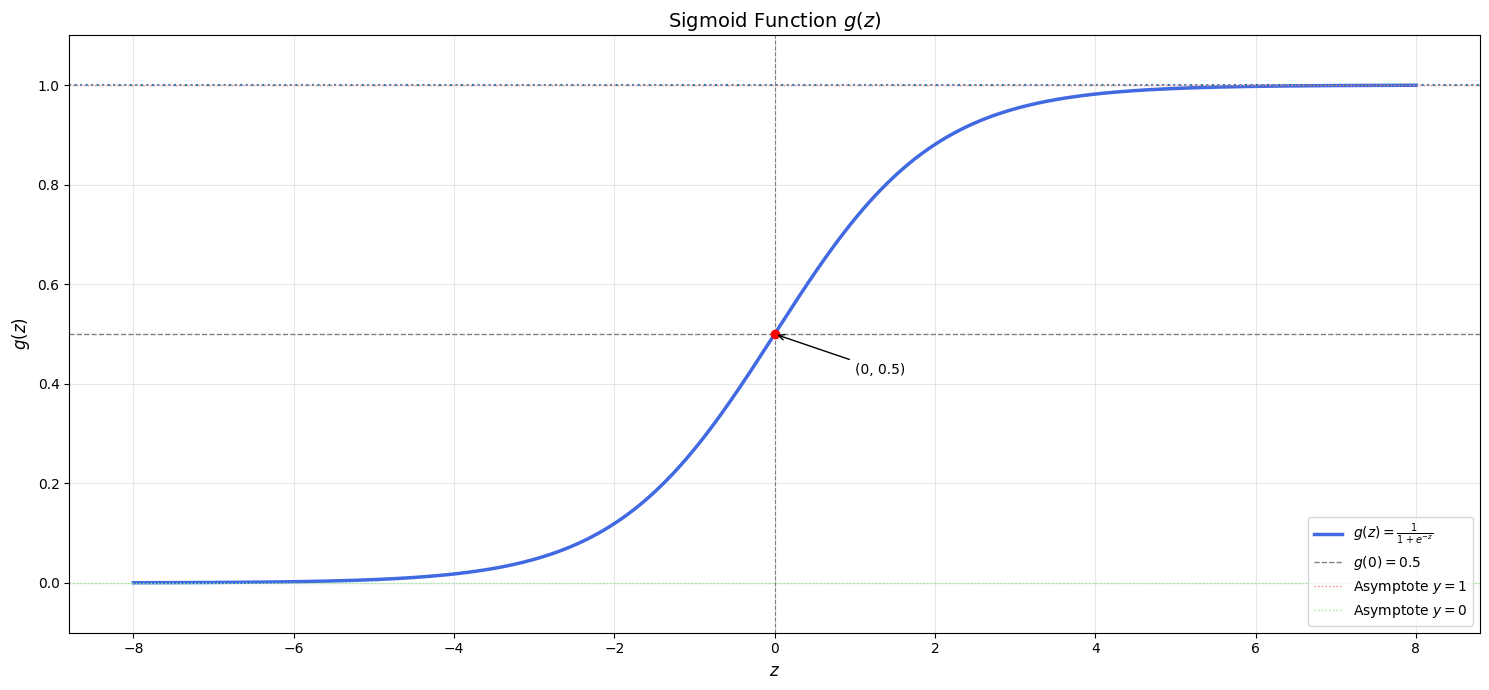

In [6]:
def sigmoid(z: np.ndarray | float) -> np.ndarray | float:
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
z = np.linspace(-8, 8, 400)
gz = sigmoid(z)

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(z, gz, color='royalblue', linewidth=2.5, label=r'$g(z)=\frac{1}{1+e^{-z}}$')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='$g(0)=0.5$')
ax.axhline(1.0, linestyle=":")
ax.axhline(1.0, color='lightcoral', linestyle=':', linewidth=1, label='Asymptote $y=1$')
ax.axhline(0.0, color='lightgreen', linestyle=':', linewidth=1, label='Asymptote $y=0$')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.scatter([0], [0.5], color='red', zorder=2)
ax.annotate('(0, 0.5)', xy=(0,0.5), xytext=(1,0.42), fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('$z$', fontsize=12)
ax.set_ylabel('$g(z)$', fontsize=12)
ax.set_title('Sigmoid Function $g(z)$', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(-0.1, 1.1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Probabilistic Interpretation**

We interpret $h_\theta(x)$ as the **conditional probability** that $y = 1$ given $x$:

$$\begin{cases}
P(y=1 \mid x;\, \theta) = h_\theta(x) \\
P(y=0 \mid x;\, \theta) = 1 - h_\theta(x)
\end{cases}$$

Both cases can be unified into a single expression:

$$P(y \mid x;\, \theta) = h_\theta(x)^{y} \cdot (1 - h_\theta(x))^{1-y}$$

**Verification:**
- When $y=1$: $P = h_\theta(x)$
- When $y=0$: $P = 1 - h_\theta(x)$

## **Likelihood and Log-Likelihood**

Assuming $m$ **independent and identically distributed** training examples, the likelihood of the observed labels is:

$$L(\theta) = \prod_{i=1}^{m} h_\theta(x^{(i)})^{y^{(i)}} \left(1 - h_\theta(x^{(i)})\right)^{1 - y^{(i)}}$$

Taking the logarithm converts the product into a sum, which is more numerically stable and easier to optimize:

$$\ell(\theta) = \sum_{i=1}^{m} \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log\left(1 - h_\theta(x^{(i)})\right) \right]$$

**Objective:** Find $\theta$ that **maximizes** $\ell(\theta)$.

Why do we maximize $\ell(\theta)$?

We want to find parameters $\theta$ that make the observed training data as probable as possible under our model. This is the **Maximum Likelihood Estimation (MLE)** principle, choose $\theta$ that assigns the highest probability to the data we actually observed.

Intuitively: if the model with parameters $\theta$ says $P(y=1 \mid x) = 0.95$ and the true label is indeed $y=1$, that is a better explanation of the data than a model that says $P(y=1 \mid x) = 0.3$. MLE formalizes this intuition, we search for the $\theta$ that makes the correct labels look most likely.

Since $L(\theta)$ and $\ell(\theta) = \log L(\theta)$ are maximized by the same $\theta$ (log is strictly increasing), we maximize $\ell(\theta)$:

$$\hat{\theta}_{MLE} = \arg\max_\theta\, \ell(\theta)$$

In [ ]:
def log_likelihood(X: np.ndarray, y: np.ndarray, theta: np.ndarray) -> float:
    h = sigmoid(X @ theta)
    eps = 1e-15
    h = np.clip(h, eps, 1- eps)
    return np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

## **Batch Gradient Ascent**

To maximize $\ell(\theta)$, we apply **gradient ascent**, updating parameters in the direction of the gradient:

$$\theta_j := \theta_j + \alpha \frac{\partial}{\partial \theta_j} \ell(\theta)$$

Recall:

$$\ell(\theta) = \sum_{i=1}^m \left[ y^{(i)} \log h^{(i)} + (1 - y^{(i)}) \log(1 - h^{(i)}) \right]$$

where $h^{(i)} = h_\theta(x^{(i)}) = g(\theta^T x^{(i)})$ and $g(z) = \dfrac{1}{1+e^{-z}}$.

Pulling the derivative inside the sum:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m \frac{\partial}{\partial \theta_j} \left( y^{(i)} \log h^{(i)} + (1 - y^{(i)}) \log(1 - h^{(i)}) \right)$$

Applying the chain rule to each term separately:

$$\frac{\partial}{\partial \theta_j}(y^{(i)} \log h^{(i)}) = y^{(i)} \frac{1}{h^{(i)}} \frac{\partial h^{(i)}}{\partial \theta_j}$$

$$\frac{\partial}{\partial \theta_j}((1-y^{(i)}) \log(1-h^{(i)})) = (1-y^{(i)}) \frac{-1}{1-h^{(i)}} \frac{\partial h^{(i)}}{\partial \theta_j}$$

Summing both terms:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m \left( \frac{y^{(i)}}{h^{(i)}} - \frac{1-y^{(i)}}{1-h^{(i)}} \right) \frac{\partial h^{(i)}}{\partial \theta_j}$$

Since $h^{(i)} = g(\theta^T x^{(i)})$, applying the chain rule:

$$\frac{\partial h^{(i)}}{\partial \theta_j} = g'(z^{(i)}) \cdot x_j^{(i)}$$

The sigmoid has a well-known derivative:

$$g'(z) = g(z)(1 - g(z))$$

Therefore:

$$\frac{\partial h^{(i)}}{\partial \theta_j} = h^{(i)}(1 - h^{(i)}) \cdot x_j^{(i)}$$

Substituting into the expression:

$$\left( \frac{y}{h} - \frac{1-y}{1-h} \right) h(1-h) \cdot x_j$$

Expanding the bracket:

$$= \left( y(1-h) - (1-y)h \right) x_j$$

$$= \left( y - yh - h + yh \right) x_j$$

$$= (y - h) \cdot x_j$$

Restoring the summation over all $m$ samples:

$$\boxed{\frac{\partial \ell(\theta)}{\partial \theta_j} = \sum_{i=1}^m \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}}$$

Stacking over all parameters $j$ simultaneously:

$$\nabla_\theta \ell(\theta) = X^T (y - h)$$

where $h = g(X\theta) \in \mathbb{R}^m$ is the vector of predicted probabilities for all samples.

The gradient ascent update rule becomes:

$$\theta := \theta + \alpha \cdot X^T (y - h)$$

In [ ]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate: float = 0.1, n_iterations: int = 1000) -> None:
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta = None
        self.history = []
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegressionScratch":
        m, n = X.shape
        self.theta = np.zeros(n)
        for _ in range(self.n_iter):
            h = sigmoid(X @ self.theta)
            gradient = X.T @ (y - h)
            self.theta += self.lr * gradient
            self.history.append(log_likelihood(X, y, self.theta))
        
        return self
        

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        "Return P(y=1|x)"
        return sigmoid(X @ self.theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def save(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self, path)
        print(f"Saved to {path}")

    @classmethod
    def load(cls, path: str) -> "LogisticRegressionScratch":
        instance = joblib.load(path)
        print(f"Loaded from {path}")
        return instance

## **Data Preparation**

## **Model Training**

## **Model Evaluation**

## **Comparision with Scikit-learn**

## **Coeficient Visualization - Feature Importance**
In Logistic Regression, the magnitude $|\theta_j|$ indicates how strongly feature $j$ influences the predicted probability, and the sign indicates the direction:
- $\theta_j > 0$ — increasing this feature raises the probability of Malignant
- $\theta_j < 0$ — increasing this feature lowers the probability of Malignant

## **Hyperparameter Tuning - From Scratch**

The from-scratch implementation has two hyperparameters:
- `learning_rate` ($\alpha$): Too large $\to$ divergence; too small $\to$ slow convergence
- `n_iterations`:  Too few $\to$ underfitting; more iterations are safe (log-likelihood is concave)

**Strategy:** Use the **validation set**, never the test set, to select the best hyperparameter combination.

### Why Log-Likelihood is concave?

A function is **concave** if and only if its Hessian matrix is **negative semi-definite** (all eigenvalues ≤ 0). We show this holds for $\ell(\theta)$.

From the derivation in the previous section, we established:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m (y^{(i)} - h^{(i)}) x_j^{(i)}$$

Differentiating again with respect to $\theta_k$:

$$\frac{\partial^2 \ell}{\partial \theta_j \partial \theta_k} = \sum_{i=1}^m -\frac{\partial h^{(i)}}{\partial \theta_k} x_j^{(i)}$$

We have already known:

$$\frac{\partial h^{(i)}}{\partial \theta_k} = h^{(i)}(1 - h^{(i)}) x_k^{(i)}$$

Substituting:

$$\frac{\partial^2 \ell}{\partial \theta_j \partial \theta_k} = -\sum_{i=1}^m h^{(i)}(1 - h^{(i)}) x_j^{(i)} x_k^{(i)}$$

The Hessian $H \in \mathbb{R}^{n \times n}$ has entries $H_{jk} = \dfrac{\partial^2 \ell}{\partial \theta_j \partial \theta_k}$, so:

$$H = -\sum_{i=1}^m h^{(i)}(1-h^{(i)}) x^{(i)} {x^{(i)}}^T = -X^T D X$$

where $D \in \mathbb{R}^{m \times m}$ is a diagonal matrix with entries:

$$D_{ii} = h^{(i)}(1 - h^{(i)})$$

For any vector $z \in \mathbb{R}^n$, we compute the quadratic form:

$$z^T H z = -z^T X^T D X z = -(Xz)^T D (Xz)$$

Let $v = Xz \in \mathbb{R}^m$. Then:

$$z^T H z = -v^T D v = -\sum_{i=1}^m D_{ii} v_i^2 = -\sum_{i=1}^m h^{(i)}(1-h^{(i)}) v_i^2$$

Since $h^{(i)} = g(z) \in (0,1)$ for all $i$, we have:

$$h^{(i)}(1 - h^{(i)}) > 0 \quad \forall\, i$$

Therefore:

$$z^T H z = -\sum_{i=1}^m \underbrace{h^{(i)}(1-h^{(i)})}_{>\ 0} \underbrace{v_i^2}_{\geq\ 0} \leq 0 \quad \forall\, z$$

This proves $H \preceq 0$, the Hessian is **negative semi-definite**.

**Consequence for optimization**

Because $H \preceq 0$ everywhere, $\ell(\theta)$ is **globally concave**, it has a single global maximum with no local maxima. This guarantees that gradient ascent will always converge to the global optimum regardless of initialization, and that running more iterations can only improve or maintain the solution, never worsen it.

## **Hyperparameter Tuning - Scikit-learn (Regularization)**

Scikit-learn's implementation adds **regularization** to penalize large coefficients and reduce overfitting:

$$\mathcal{L}_{reg}(\theta) = \ell(\theta) - \lambda \|\theta\|^2 \quad \text{(L2 / Ridge)}$$

The regularization strength is controlled by `C = 1/λ`: smaller `C` → stronger regularization (simpler model); larger `C` → weaker regularization (closer to unregularized).

We use `GridSearchCV` with 5-fold stratified cross-validation to select the optimal `C` and `penalty`.